In [1]:
import os, glob, shutil, zipfile, gdown
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorboard as tb
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks, optimizers, losses
%matplotlib inline

# Load the TensorBoard notebook extension
%load_ext tensorboard

# metrics
from sklearn import metrics

In [2]:
# Global Variables
FILE_ID = "1FOpBqxqZRkAkv1rlTPw1ZLME1wG_tJOv"
tf.keras.utils.set_random_seed(111)
height, width = 128, 128
channels = 3

In [22]:
# Utility Function

# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

# function to unzip the file
def unzip_file_shutil(zip_path, extract_path):
    try:
        os.makedirs(extract_path, exist_ok=True)
        shutil.unpack_archive(zip_path, extract_path)
        print(f"Successfully extracted to {extract_path}")
    except Exception as e:
        print(f"Error extracting file: {e}")

def deleteLogs(log_path=""):

    if not log_path:
        log_path = os.path.join(os.getcwd(), "logs")
    try:
        shutil.rmtree(log_path)
        print(f"Deleted logs from {log_path}")
    except Exception as e:
        print(f"Error deleting logs: {e}")

def generate_logs_Folder(logfolderName="", clear_folder=False):
    currentPath = os.getcwd()

    # clear existing eventLogs if clear_folder is True
    if clear_folder:
        deleteLogs(os.path.join(currentPath, "logs"))

    if not os.path.exists(os.path.join(currentPath, "logs")):
        os.mkdir("logs")

    if logfolderName:
        logfolderName = logfolderName + "_" + time.strftime("%Y%m%d-%H%M%S")
        logName = os.path.join(currentPath, "logs", logfolderName)
        if not os.path.exists(logName):
            os.mkdir(logName)
    else:
        logName = os.path.join(currentPath, "logs")
    
    return logName

def generate_logs_Name(fileName, logFormat=".log", clear_folder=False):
    folderName = generate_logs_Folder(fileName, clear_folder=clear_folder)
    fileName = fileName + "_" + time.strftime("%Y%m%d-%H%M%S") + logFormat
    return os.path.join(folderName, fileName)

In [4]:
def download_and_prep_dataset(FILE_ID):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSet_path = os.path.abspath(os.path.join(currentPath, "../dataSet/cloth_dataSet_small.zip"))
    extractPath = os.path.abspath(os.path.join(currentPath, "../unzipLoc/"))

    # create directory if not exists
    if not os.path.exists(os.path.abspath(os.path.join(currentPath, "../dataSet/"))):
        os.mkdir(os.path.abspath(os.path.join(currentPath, "../dataSet/")))

    if not os.path.exists(extractPath):
        os.mkdir(extractPath)

    # download the dataset
    if not os.path.exists(dataSet_path):
        download_dataset_from_url(url=url, file_path=dataSet_path)

    # unzip the dataset
    if os.listdir(extractPath) == []:
        unzip_file_shutil(zip_path=dataSet_path, extract_path=extractPath)
    
    # Load the dataset
    data_path = os.path.join(extractPath, "clothing-dataset-small")
    return data_path

def preprocess(train_data, val_data, test_data, target_height=128, target_width=128):

    # Data Processing Stage with resizing and rescaling operations
    data_preprocess = keras.Sequential(
        name="data_preprocess",
        layers=[
            layers.Resizing(target_height, target_width),
            layers.Rescaling(1.0/255),
        ]
    )

    # Perform Data Processing on the train, val, test dataset
    train_ds = train_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

In [5]:
# prepare the Dataset
dl_ext_data_path = download_and_prep_dataset(FILE_ID=FILE_ID)
print(dl_ext_data_path)

# Check the dataset Paths
train_path = os.path.join(dl_ext_data_path, "train")
test_path = os.path.join(dl_ext_data_path, "test")
val_path = os.path.join(dl_ext_data_path, "validation")

assert os.path.exists(train_path), "Train path does not exist"
assert os.path.exists(test_path), "Test path does not exist"
assert os.path.exists(val_path), "Val path does not exist"

# Load the dataset
Train_DS = tf.keras.utils.image_dataset_from_directory(directory=train_path, shuffle=True, image_size=(height, width))
Test_DS = tf.keras.utils.image_dataset_from_directory(directory=test_path, shuffle=True, image_size=(height, width))
Val_DS = tf.keras.utils.image_dataset_from_directory(directory=val_path, shuffle=True, image_size=(height, width))

# Scale the DataSet
Train_scaled, Test_scaled, Val_scaled = preprocess(Train_DS, Val_DS, Test_DS, target_height=height, target_width=width)
classNames = Train_DS.class_names

CWD:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks
c:\Study\gitRepo\CV_Amazon_Cloth_Classify\unzipLoc\clothing-dataset-small
Found 3068 files belonging to 10 classes.
Found 372 files belonging to 10 classes.
Found 341 files belonging to 10 classes.


In [ ]:
## Create CNN Model
# Base Line Model
def create_base_model(model_name="cnn_Model"):
    inpLayer = layers.Input(shape=(height, width, channels))
    conv2D_1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu') (inpLayer)
    maxPool_1 = layers.MaxPooling2D() (conv2D_1)
    flatten = layers.Flatten() (maxPool_1)
    dense_1 = layers.Dense(units=128, activation='relu') (flatten)
    output = layers.Dense(units=len(classNames), activation='softmax') (dense_1)

    model = keras.Model(inputs=inpLayer, outputs=output, name=model_name)
    return model

def start_model_training(model, train_data, val_data, epochs=10, model_name="base_model"):
    model.compile(optimizer=optimizers.Adam(),
                  loss=losses.SparseCategoricalCrossentropy(),
                  metrics=["accuracy"])
    
    logName = generate_logs_Name(fileName=model_name, logFormat=".log", clear_folder=False)
    csvLogger = callbacks.CSVLogger(filename=logName)
    tensorBoardLogs = generate_logs_Folder(logfolderName=model_name+"_tb_logs", clear_folder=False)
    tensorBoard = callbacks.TensorBoard(log_dir=tensorBoardLogs, histogram_freq=1)
    modelCheckpoint = callbacks.ModelCheckpoint(filepath=model_name+"_best_model.keras",
                                                save_best_only=True,
                                                monitor="val_accuracy",
                                                mode="max")

    history = model.fit(train_data,
                        validation_data=val_data,
                        epochs=epochs,
                        callbacks=[tensorBoard, csvLogger, modelCheckpoint],
                        verbose=1)
    return history

In [10]:
baseModel = create_base_model()
baseModel.summary()

Model: "cnn_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,779,530 (64.01 MB)

 Trainable params: 16,779,530 (64.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = start_model_training(model=baseModel,
                               model_name="base_model",
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=10)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.2727 - loss: 4.1713 - val_accuracy: 0.3360 - val_loss: 1.9298
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.5266 - loss: 1.4329 - val_accuracy: 0.4597 - val_loss: 1.5930
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 147ms/step - accuracy: 0.7229 - loss: 0.9178 - val_accuracy: 0.5269 - val_loss: 1.4711
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.8573 - loss: 0.5222 - val_accuracy: 0.4919 - val_loss: 1.5011
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.9394 - loss: 0.2805 - val_accuracy: 0.5349 - val_loss: 1.4961
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 149ms/step - accuracy: 0.9689 - loss: 0.1568 - val_accuracy: 0.5323 - val_loss: 1.5621
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.9857 - loss: 0.1022 - val_accuracy: 0.5027 - val_loss: 1.7142
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.9929 - loss: 0.0588 - val_accu

<Figure size 1000x500 with 0 Axes>

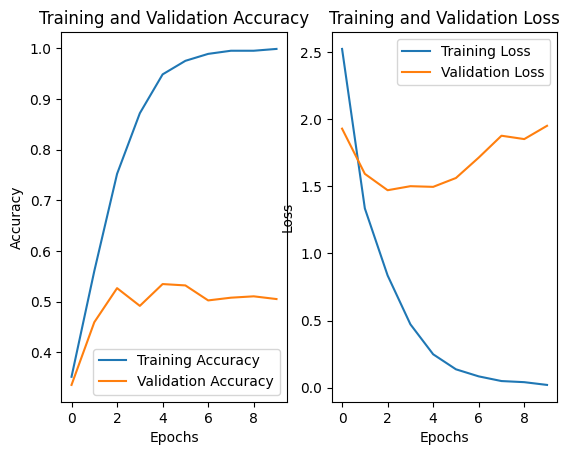

In [16]:
trainAcc = history.history["accuracy"]
valAcc = history.history["val_accuracy"]

trainLoss = history.history["loss"]
valLoss = history.history["val_loss"]

# Plot the Training and Validation Accuracy
plt.figure(figsize=(10, 5))
fig, ax = plt.subplots(ncols=2, nrows=1)
ax[0].plot(trainAcc, label="Training Accuracy")
ax[0].plot(valAcc, label="Validation Accuracy")
ax[0].set_title("Training and Validation Accuracy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

# Plot the Training and Validation Loss
ax[1].plot(trainLoss, label="Training Loss")
ax[1].plot(valLoss, label="Validation Loss")
ax[1].set_title("Training and Validation Loss")
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")
ax[1].legend()

plt.show()

The model is quite over fitting.

Techniques to reduce overfitting.
1) L1/L2 regularization
2) Dropout
3) Learning Rate scheduler
4) Model Architecture (make it simpler)
5) GAP (CNN specific)

In [20]:
# adding Regularization to the model and make model simpler

# Gap_Deep Model
def create_deep_gap_model(model_name="cnn_Model"):
    inpLayer = layers.Input(shape=(height, width, channels))
    conv2D_1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu') (inpLayer)
    maxPool_1 = layers.MaxPooling2D() (conv2D_1)
    conv2D_2 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation='relu') (maxPool_1)
    maxPool_2 = layers.MaxPooling2D() (conv2D_2)
    conv2D_3 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation='relu') (maxPool_2)
    maxPool_3 = layers.MaxPooling2D() (conv2D_3)
    gapLayer = layers.GlobalAveragePooling2D() (maxPool_3)
    dense_1 = layers.Dense(units=256, activation='relu') (gapLayer)
    output = layers.Dense(units=len(classNames), activation='softmax') (dense_1)

    model = keras.Model(inputs=inpLayer, outputs=output, name=model_name)
    return model

def start_model_training(model, train_data, val_data, epochs=10, model_name="base_model"):
    model.compile(optimizer=optimizers.Adam(),
                  loss=losses.SparseCategoricalCrossentropy(),
                  metrics=["accuracy"])
    
    logName = generate_logs_Name(fileName=model_name, logFormat=".log", clear_folder=False)
    csvLogger = callbacks.CSVLogger(filename=logName)
    tensorBoardLogs = generate_logs_Folder(logfolderName=model_name+"_tb_logs", clear_folder=False)
    tensorBoard = callbacks.TensorBoard(log_dir=tensorBoardLogs, histogram_freq=1)
    modelCheckpoint = callbacks.ModelCheckpoint(filepath=model_name+"_best_model.keras",
                                                save_best_only=True,
                                                monitor="val_accuracy",
                                                mode="max")

    history = model.fit(train_data,
                        validation_data=val_data,
                        epochs=epochs,
                        callbacks=[tensorBoard, csvLogger, modelCheckpoint],
                        verbose=1)
    return history

In [24]:
deep_gap_model = create_deep_gap_model(model_name="deep_gap_model")
deep_gap_model.summary()
# deleteLogs(log_path="")

Model: "deep_gap_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,842 (503.29 KB)

 Trainable params: 128,842 (503.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = start_model_training(model=deep_gap_model,
                               model_name="deep_GAP_model",
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=10)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.2541 - loss: 2.1572 - val_accuracy: 0.1398 - val_loss: 2.2918
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.2703 - loss: 2.0943 - val_accuracy: 0.1425 - val_loss: 2.2631
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.2729 - loss: 2.0782 - val_accuracy: 0.1613 - val_loss: 2.2173
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.2883 - loss: 2.0347 - val_accuracy: 0.1478 - val_loss: 2.2197
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.3077 - loss: 1.9961 - val_accuracy: 0.1774 - val_loss: 2.2356
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.3375 - loss: 1.9297 - val_accuracy: 0.1801 - val_loss: 2.2100
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.3549 - loss: 1.8495 - val_accuracy: 0.2231 - val_loss: 2.0838
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.3694 - loss: 1.8061 - val_accuracy: 0.2446 - 

In [ ]:
history